In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.DataFrame(pd.read_csv('dataset.csv'))

In [3]:
y=np.load('labels.npy')

In [4]:
df['Label']=y

In [5]:
print("INFO/n")
print(df.info(),"/n")
print("DESCRIBBE/n")
print(df.describe())
print("Correlation/n")
print(df.corr(),"/n")

INFO/n
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   profile_age_days         10000 non-null  int64  
 1   applications_7d          10000 non-null  int64  
 2   applications_30d         10000 non-null  int64  
 3   avg_applications_30d     10000 non-null  float64
 4   app_to_avg_ratio         10000 non-null  float64
 5   skills_count             10000 non-null  int64  
 6   endorsements_count       10000 non-null  int64  
 7   experience_years         10000 non-null  float64
 8   skills_to_exp_ratio      10000 non-null  float64
 9   institution_risk_score   10000 non-null  float64
 10  company_risk_score       10000 non-null  float64
 11  gpa_anomaly_score        10000 non-null  float64
 12  tenure_gap_months        10000 non-null  float64
 13  avg_tenure_months        10000 non-null  float64
 14  time_since_last_

In [6]:
df.corr()['Label'].sort_values(ascending=False)

Label                      1.000000
applications_7d            0.345794
applications_30d           0.343210
login_velocity_24h         0.331933
skills_to_exp_ratio        0.293703
app_to_avg_ratio           0.240758
failed_logins_24h          0.188211
tenure_gap_months          0.178334
institution_risk_score     0.152355
company_risk_score         0.149222
gpa_anomaly_score          0.140876
email_risk_score           0.140366
copy_paste_ratio           0.106294
is_new_device              0.091878
feature_noise_2            0.018228
feature_noise_1            0.015412
endorsements_count         0.006062
ip_risk_score              0.003993
feature_noise_4           -0.003011
skills_count              -0.010301
avg_tenure_months         -0.011642
avg_applications_30d      -0.013562
feature_noise_3           -0.017635
experience_years          -0.017851
time_since_last_app_hrs   -0.018817
profile_age_days          -0.061872
Name: Label, dtype: float64

In [7]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

def engineer_features(df):
    """
    Optimized Feature Suite: Focuses on interaction ratios 
    that fraudsters find difficult to spoof.
    """
    # 1. Remove noise features that degrade mathematical distance
    noise_cols = [c for c in df.columns if 'noise' in c]
    df_clean = df.drop(columns=noise_cols)
    
    # 2. Account Takeover Indicator (Device + Failure interaction)
    df_clean['login_danger_score'] = df_clean['is_new_device'] * (df_clean['failed_logins_24h'] + 1)
    
    # 3. App Bombing Indicator (Activity Velocity)
    df_clean['app_velocity'] = df_clean['applications_7d'] / (df_clean['profile_age_days'] + 1)
    
    # 4. Ghost Profile Indicator (Skill Saturation)
    df_clean['skill_saturation'] = df_clean['skills_count'] / (df_clean['experience_years'] + 0.5)
    
    # 5. Global Risk Aggregate
    risk_cols = ['ip_risk_score', 'email_risk_score', 'institution_risk_score', 'company_risk_score']
    df_clean['total_risk_magnitude'] = df_clean[risk_cols].mean(axis=1)
    
    return df_clean

# --- EXECUTION PIPELINE ---

# 1. Load and Prepare
df = pd.read_csv('dataset.csv')
df_eng = engineer_features(df)

# 2. Scale features (Critical for K-Means and Isolation Forest)
scaler = StandardScaler()
# Drop 'Label' for the selection phase if it exists locally
X = df_eng.drop(columns=['Label'], errors='ignore')
X_scaled = scaler.fit_transform(X)

# 3. Mathematical Anomaly Detection (Fixed fit/decision_function logic)
iso = IsolationForest(contamination=0.08, random_state=42)
iso.fit(X_scaled)
# Higher score = normal, Lower score = anomalous
df_eng['anomaly_score'] = iso.decision_function(X_scaled)

# 4. Diversity Clustering (Ensures we catch all 4 types of scams)
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
df_eng['cluster'] = kmeans.fit_predict(X_scaled)

# 5. Strategic Sampling: Pick top 10 anomalies from each of the 10 clusters
query_indices = []
for i in range(10):
    cluster_subset = df_eng[df_eng['cluster'] == i]
    # We want the lowest anomaly_score (the most 'weird' ones)
    top_anomalies = cluster_subset.sort_values('anomaly_score').head(10).index
    query_indices.extend(top_anomalies.tolist())

# --- FINAL OUTPUT ---
# These are the 100 indices you should send to the Oracle
print(f"Strategic Query Indices (Total {len(query_indices)}):")
print(query_indices)

Strategic Query Indices (Total 100):
[8470, 7553, 5474, 7768, 8057, 7228, 3872, 8955, 4011, 731, 6591, 6895, 6879, 7790, 2651, 2487, 1518, 877, 4229, 1625, 2067, 6529, 43, 2580, 382, 8118, 4937, 6477, 6555, 6508, 8012, 6134, 5975, 9433, 1649, 1229, 312, 8318, 4069, 7101, 3119, 6900, 9936, 3988, 7174, 7296, 3567, 6745, 6095, 8636, 218, 1050, 7143, 4187, 6977, 474, 7735, 6468, 597, 6702, 5022, 6184, 784, 8336, 5179, 1807, 2235, 8196, 8843, 1499, 3732, 6797, 3600, 2757, 2930, 8870, 5449, 8962, 6678, 4909, 1964, 6502, 248, 1272, 3243, 1136, 832, 9404, 7206, 2071, 9770, 1426, 7893, 6704, 962, 5596, 1195, 4329, 3907, 7468]


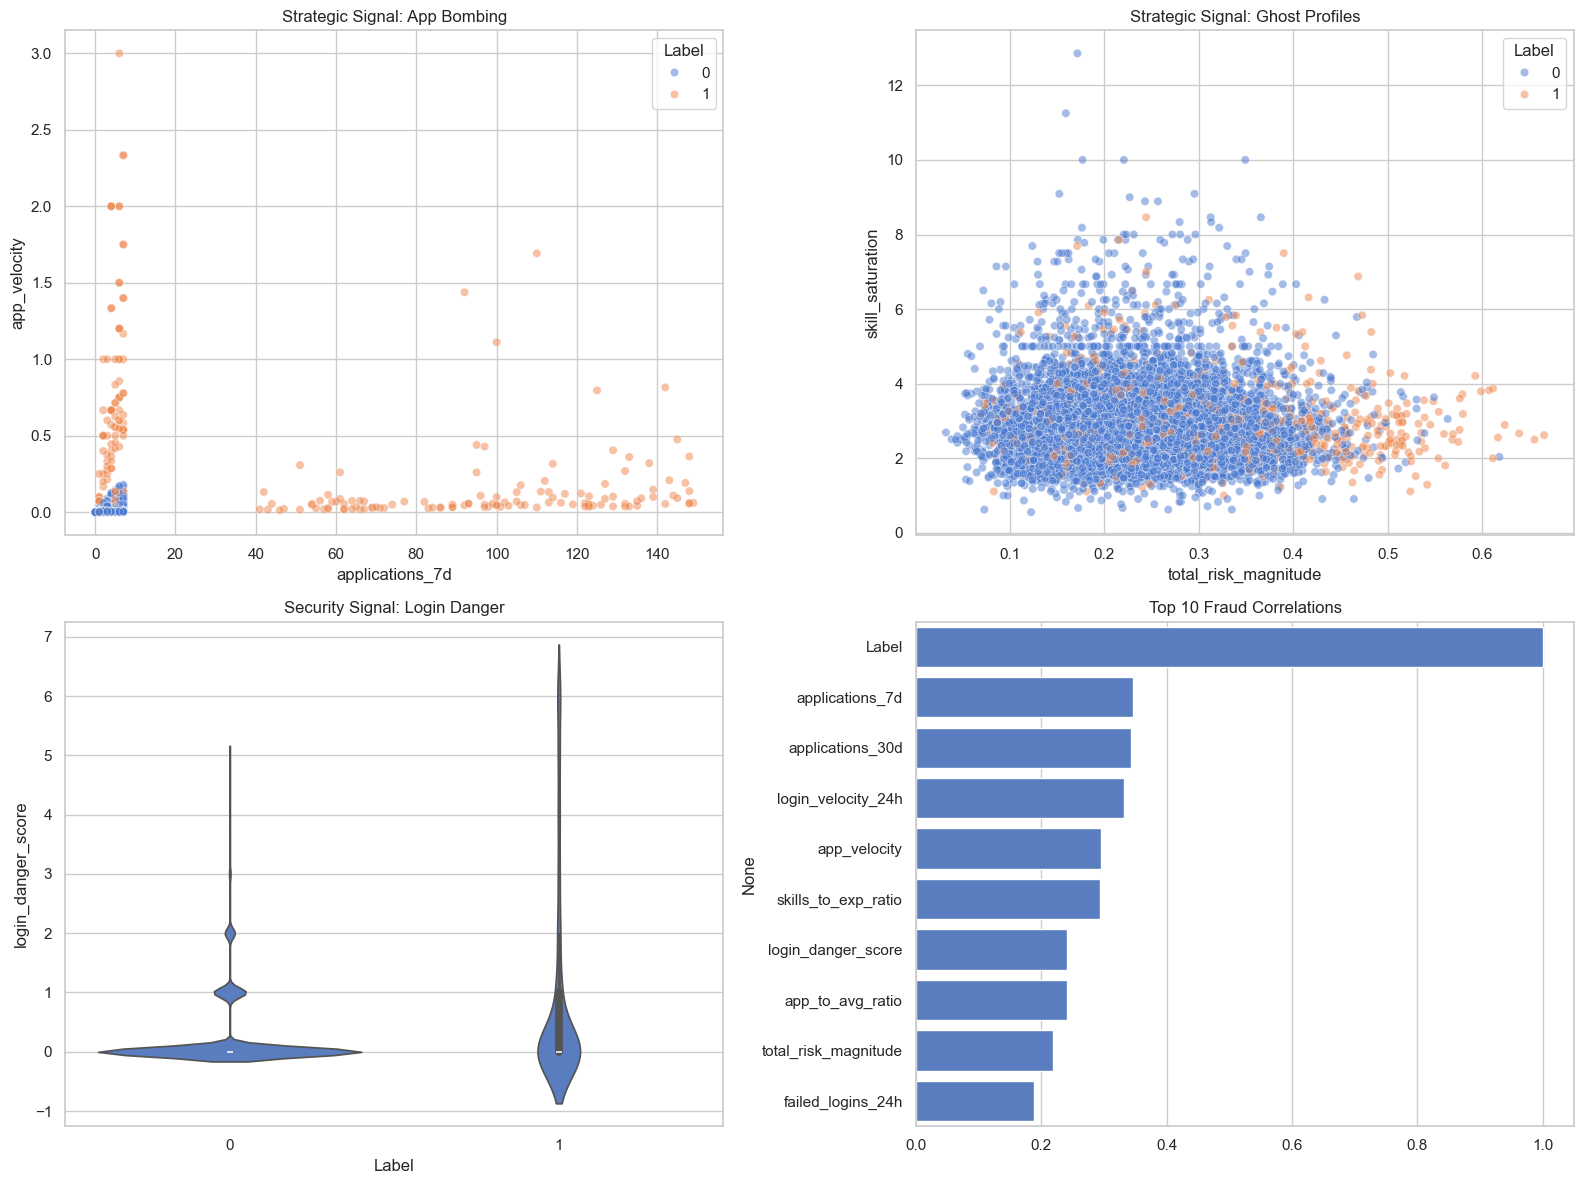

In [8]:
def plot_fraud_indicators(df_viz):
    sns.set(style="whitegrid", palette="muted")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: App Bombing (Activity vs Velocity)
    sns.scatterplot(data=df_viz, x='applications_7d', y='app_velocity', 
                    hue='Label', ax=axes[0,0], alpha=0.5)
    axes[0,0].set_title('Strategic Signal: App Bombing')

    # Plot 2: Credential Fraud (Risk Magnitude vs Saturation)
    sns.scatterplot(data=df_viz, x='total_risk_magnitude', y='skill_saturation', 
                    hue='Label', ax=axes[0,1], alpha=0.5)
    axes[0,1].set_title('Strategic Signal: Ghost Profiles')

    # Plot 3: Account Takeover (Violin of Danger Score)
    sns.violinplot(data=df_viz, x='Label', y='login_danger_score', ax=axes[1,0])
    axes[1,0].set_title('Security Signal: Login Danger')

    # Plot 4: Correlation Heatmap (Feature Importance)
    top_corr = df_viz.corr()['Label'].sort_values(ascending=False).head(10)
    sns.barplot(x=top_corr.values, y=top_corr.index, ax=axes[1,1])
    axes[1,1].set_title('Top 10 Fraud Correlations')

    plt.tight_layout()
    plt.show()

# Note: This requires the Label column for visualization
# For local testing, load your labels.npy
labels = np.load('labels.npy')
df_eng['Label'] = labels
plot_fraud_indicators(df_eng)